
# VLA-style layer-locked readout vs. closed-form EI

Trains `models/layer_locked_readout.py`'s `LayerLockedReadout` (the VLA-action-expert-style,
per-PFN-layer sequential cross-attention readout — see that module's docstring for the full
rationale vs. `docs/ROADMAP.md` §3.2's flat-concat design) to predict EI, using ONLY the frozen
PFN's train-token hidden states — never the frozen model's own query-conditioned output. Ground
truth is the closed-form EI from the SAME frozen model's own bar distribution
(`model.bar_dist.ei`), on the SAME BNN instance and the SAME train/query points the readout sees.

**Incumbent marker: one per layer, not once at the start.** The marker is added directly to each
layer's already-computed frozen hidden state (`H^l[incumbent_idx] += marker[l]`) — it never
touches the frozen PFN's own forward pass, which already finished computing `H^0, ..., H^{L-1}`
independently before the readout ever runs. Because of that, marking only feeds back through the
readout's OWN residual stream (`h`, layer to layer); it does NOT propagate into the frozen model's
per-layer outputs the way an input-level marker (e.g. BERT's segment embedding) would. Marking once
at the very first layer would leave every later cross-attention round reading an un-marked `H^l`
(the incumbent's token at layer `l>0` looks like any other train token), with no reliable way for
the readout to relocate it. So each layer needs its own marker for the mechanism to work at every
round — that's what's implemented, `n_layers` separate learned vectors, not one shared or applied
only once.

Ground-truth EI computed via `model.bar_dist.ei(logits, best_f=y_incumbent.unsqueeze(-1))` — the
`.unsqueeze(-1)` matters: `BarDistribution.ei()` now asserts `best_f.dim() == logits.dim() - 1`
after a bug where omitting it silently mixed up different environments' incumbents (see
`models/bar_distribution.py` and its regression tests). Target is `log10(EI / best_f)`, not
`log10(EI)` directly — EI is bounded to `[0, best_f] ⊆ [0,1]` here (the checkpoint's bar
distribution has fixed `[0,1]` borders, not an unbounded tail), so normalizing by `best_f` removes
cross-environment scale as a confound and makes `log10(·) ≤ 0` an exact bound, not incidental.

**A note on the scatter plot's spread.** Unlike a realized (Monte Carlo) reward target, `ei_true`
is a DETERMINISTIC, closed-form function of `(x_train, y_train, x_query)` — there is no intrinsic
label noise here. So any spread around `y = x` in the log-log scatter is entirely readout
prediction error, not an irreducible noise floor; it should, in principle, keep shrinking with more
training/capacity rather than plateau at some inherent limit. Log-log axes also visually exaggerate
spread for a heavy-tailed quantity spanning many decades — a fixed *relative* error looks wider at
the low end than the high end purely from the log compression — so this notebook reports the
log-space MAE/RMSE and per-instance rank statistics alongside the plot, not just the picture.

**Run config:** long budget, GPU (`ulysses`) — see `N_STEPS` below; auto-detects `cuda`.


In [1]:

import time

import matplotlib.pyplot as plt
import numpy as np
import torch
from scipy.stats import spearmanr

from anytimeacquisition.models.bar_distribution import BarDistribution, uniform_bin_borders
from anytimeacquisition.models.layer_locked_readout import LayerLockedReadout, load_checkpoint, save_checkpoint
from anytimeacquisition.pipelines.train_pfn import load_pfn_checkpoint
from anytimeacquisition.priors.bnn import BNNPrior

torch.manual_seed(0)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

PFN_CHECKPOINT_PATH = "../models/pfn_variable_xdim_smoke.pt"
model, _, ckpt = load_pfn_checkpoint(PFN_CHECKPOINT_PATH, device=device)
model.eval()
for p in model.parameters():
    p.requires_grad_(False)
print("frozen PFN config:", ckpt["config"])

X_DIM = ckpt["config"]["max_x_dim"]
D_MODEL_PFN = ckpt["config"]["d_model"]
N_LAYERS = ckpt["config"]["n_layers"]


/home/ruhkopf/PycharmProjects/AnytimeAcquisition/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device: cuda
frozen PFN config: {'max_x_dim': 6, 'd_model': 64, 'n_heads': 4, 'n_layers': 4, 'd_ff': 128, 'n_bins': 64}


In [2]:

D_EXPERT, N_HEADS_EXPERT, D_FF_EXPERT = 32, 4, 64
N_BINS, Z_LO, Z_HI, EPS = 64, -6.0, 0.0, 1e-8

readout = LayerLockedReadout(D_MODEL_PFN, D_EXPERT, N_HEADS_EXPERT, N_LAYERS, D_FF_EXPERT, X_DIM, N_BINS).to(device)
bar_dist_score = BarDistribution(uniform_bin_borders(N_BINS, lo=Z_LO, hi=Z_HI)).to(device)
opt = torch.optim.Adam(readout.parameters(), lr=1e-3)
print(f"readout params: {sum(p.numel() for p in readout.parameters()):,}")


readout params: 45,024


In [3]:

BATCH_SIZE, N_QUERY, N_TRAIN_RANGE = 32, 32, (3, 20)
prior = BNNPrior(batch_size=BATCH_SIZE, x_dim=X_DIM, variable_dim_min=1, device=device, seed=1)


def sample_batch(generator=None):
    prior.reset()
    n_train = torch.randint(N_TRAIN_RANGE[0], N_TRAIN_RANGE[1] + 1, (1,), generator=generator).item()
    x_train, y_train, x_query, _ = prior.sample_episode(n_train=n_train, n_test=N_QUERY)

    with torch.no_grad():
        logits_frozen, hidden_states = model(x_train, y_train, x_query, return_hidden=True)
        y_incumbent = y_train.min(dim=1).values
        incumbent_idx = y_train.argmin(dim=1)
        train_hidden = [h[:, :n_train] for h in hidden_states]

        ei_true = model.bar_dist.ei(logits_frozen, best_f=y_incumbent.unsqueeze(-1))  # [B, n_query]
        r_true = (ei_true / y_incumbent.unsqueeze(-1).clamp_min(EPS)).clamp(0.0, 1.0)
        z_true = torch.log10(r_true.clamp_min(EPS)).clamp(Z_LO, Z_HI)

    return x_query, train_hidden, incumbent_idx, y_incumbent, ei_true, z_true


# Fixed held-out probe set for a low-noise learning curve -- 10 batches
# (320 instances) rather than 5, since the long run below can afford it and
# per-instance rank statistics get noisy with too few instances.
val_gen = torch.Generator(device="cpu").manual_seed(123)  # torch.randint's output tensor is CPU by
# default (no device= passed below), so its generator must be CPU too, regardless of `device` --
# a CUDA generator here raises "Expected a 'cpu' device type for generator but found 'cuda'".
VAL_BATCHES = [sample_batch(generator=val_gen) for _ in range(10)]


In [4]:

def evaluate():
    losses, ei_gaps = [], []
    with torch.no_grad():
        for x_query, train_hidden, incumbent_idx, y_incumbent, ei_true, z_true in VAL_BATCHES:
            logits = readout(x_query, train_hidden, incumbent_idx)
            losses.append(bar_dist_score.forward(logits, z_true).mean().item())
            r_pred = 10.0 ** bar_dist_score.mean(logits)
            ei_pred = r_pred * y_incumbent.unsqueeze(-1)
            ei_gaps.append((ei_pred - ei_true).abs().mean().item())
    return sum(losses) / len(losses), sum(ei_gaps) / len(ei_gaps)


N_STEPS = 200_000  # 20k ran in 347s on ulysses's RTX 3090 -- neither loss nor EI gap had
# plateaued yet, and per-step cost is cheap enough to push considerably further.
LOG_EVERY = 1000
history = {"step": [], "train_loss": [], "val_loss": [], "val_ei_gap": []}

t0 = time.time()
for step in range(N_STEPS):
    x_query, train_hidden, incumbent_idx, y_incumbent, ei_true, z_true = sample_batch()
    logits = readout(x_query, train_hidden, incumbent_idx)
    loss = bar_dist_score.forward(logits, z_true).mean()

    opt.zero_grad()
    loss.backward()
    opt.step()

    if step % LOG_EVERY == 0 or step == N_STEPS - 1:
        val_loss, val_ei_gap = evaluate()
        history["step"].append(step)
        history["train_loss"].append(loss.item())
        history["val_loss"].append(val_loss)
        history["val_ei_gap"].append(val_ei_gap)
        print(f"step {step:6d}  loss {loss.item():.3f}/{val_loss:.3f}  "
              f"EI gap (MAE) {val_ei_gap:.4f}  elapsed {time.time() - t0:.0f}s")

print(f"total training time: {time.time() - t0:.0f}s")


step      0  loss 2.128/1.970  EI gap (MAE) 0.0082  elapsed 0s


step   1000  loss 0.079/0.368  EI gap (MAE) 0.0039  elapsed 18s


step   2000  loss 0.174/0.246  EI gap (MAE) 0.0032  elapsed 36s


step   3000  loss 0.356/0.153  EI gap (MAE) 0.0030  elapsed 53s


step   4000  loss 0.299/0.158  EI gap (MAE) 0.0032  elapsed 71s


...

step 196000  loss -0.921/-0.629  EI gap (MAE) 0.0013  elapsed 3311s


step 197000  loss -0.685/-0.602  EI gap (MAE) 0.0013  elapsed 3328s


step 198000  loss -0.577/-0.591  EI gap (MAE) 0.0013  elapsed 3345s


step 199000  loss -0.954/-0.601  EI gap (MAE) 0.0014  elapsed 3362s


step 199999  loss -0.564/-0.628  EI gap (MAE) 0.0013  elapsed 3379s
total training time: 3379s


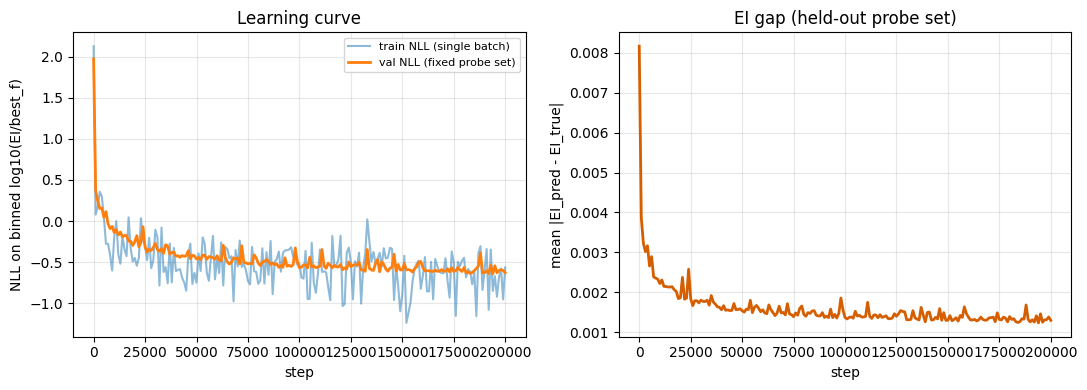

In [5]:

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(history["step"], history["train_loss"], alpha=0.5, label="train NLL (single batch)")
axes[0].plot(history["step"], history["val_loss"], linewidth=2, label="val NLL (fixed probe set)")
axes[0].set_xlabel("step")
axes[0].set_ylabel("NLL on binned log10(EI/best_f)")
axes[0].set_title("Learning curve")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

axes[1].plot(history["step"], history["val_ei_gap"], color="#D55E00", linewidth=2)
axes[1].set_xlabel("step")
axes[1].set_ylabel("mean |EI_pred - EI_true|")
axes[1].set_title("EI gap (held-out probe set)")
axes[1].grid(alpha=0.3)

fig.tight_layout()
fig.savefig("_demo_plots/vla_readout_ei_fit_learning_curve.png", dpi=150, bbox_inches="tight")
plt.show()



## Ranking diagnostics

Pooled correlation across many instances can look good even when within-instance ranking (the
thing that actually matters for picking a next query) is weak -- this is exactly what the earlier,
buggy version of this experiment showed (pooled Spearman 0.56 vs. per-instance 0.13). Reporting
both here, plus top-1 hit rate (does `argmax(predicted EI)` pick the actual best candidate) and the
log-space error (a scale-appropriate number to interpret the scatter plot's spread against).


In [6]:

per_instance_rho, top1_hit, z_err = [], [], []
all_ei_true, all_ei_pred = [], []

with torch.no_grad():
    for x_query, train_hidden, incumbent_idx, y_incumbent, ei_true, z_true in VAL_BATCHES:
        logits = readout(x_query, train_hidden, incumbent_idx)
        z_pred = bar_dist_score.mean(logits)
        ei_pred = (10.0 ** z_pred) * y_incumbent.unsqueeze(-1)

        z_err.append((z_pred - z_true).cpu().numpy().flatten())
        all_ei_true.append(ei_true.cpu().flatten())
        all_ei_pred.append(ei_pred.cpu().flatten())

        ei_true_np, ei_pred_np = ei_true.cpu().numpy(), ei_pred.cpu().numpy()
        for b in range(ei_true_np.shape[0]):
            true_b, pred_b = ei_true_np[b], ei_pred_np[b]
            if np.unique(true_b).size > 1:
                rho_b, _ = spearmanr(true_b, pred_b)
                per_instance_rho.append(rho_b)
            top1_hit.append(int(true_b.argmax()) == int(pred_b.argmax()))

per_instance_rho = np.array(per_instance_rho)
z_err = np.concatenate(z_err)
ei_true_cat = torch.cat(all_ei_true).numpy()
ei_pred_cat = torch.cat(all_ei_pred).numpy()
pooled_rho, _ = spearmanr(ei_true_cat, ei_pred_cat)

print(f"pooled Spearman:         {pooled_rho:.4f}")
print(f"per-instance Spearman:   mean {per_instance_rho.mean():.3f}  median {np.median(per_instance_rho):.3f}  "
      f"std {per_instance_rho.std():.3f}  (n={len(per_instance_rho)} instances)")
print(f"top-1 hit rate:          {np.mean(top1_hit):.3f}  ({sum(top1_hit)}/{len(top1_hit)} instances; "
      f"random chance = {1 / N_QUERY:.3f})")
print(f"log10(EI/best_f) error:  MAE {np.abs(z_err).mean():.3f}  RMSE {np.sqrt((z_err ** 2).mean()):.3f}  "
      f"(~{10 ** np.abs(z_err).mean():.2f}x typical multiplicative error)")


pooled Spearman:         0.9869
per-instance Spearman:   mean 0.932  median 0.953  std 0.068  (n=320 instances)
top-1 hit rate:          0.700  (224/320 instances; random chance = 0.031)
log10(EI/best_f) error:  MAE 0.110  RMSE 0.158  (~1.29x typical multiplicative error)


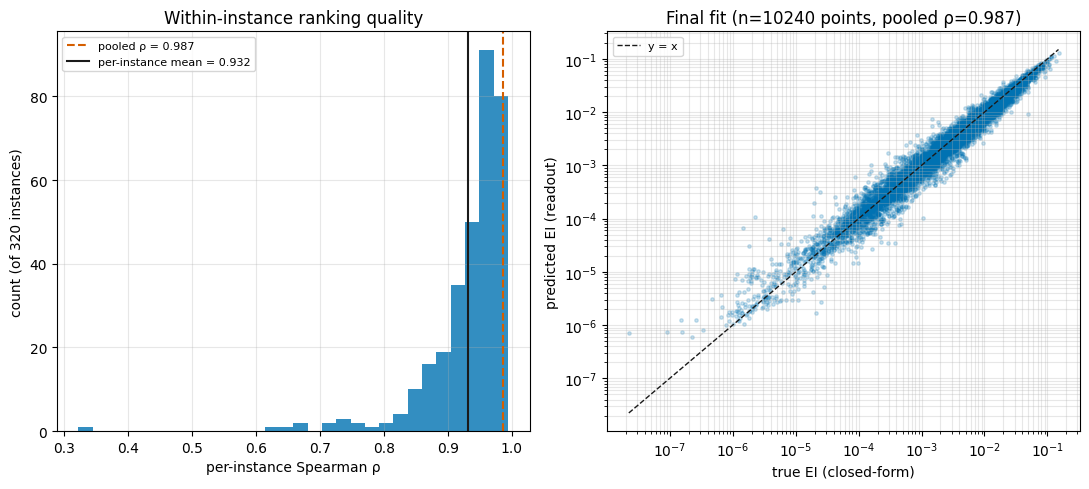

final EI gap (MAE, held-out): 0.0013
final val NLL:                -0.6284


In [7]:

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

axes[0].hist(per_instance_rho, bins=30, color="#0072B2", alpha=0.8)
axes[0].axvline(pooled_rho, color="#D55E00", linestyle="--", label=f"pooled ρ = {pooled_rho:.3f}")
axes[0].axvline(per_instance_rho.mean(), color="#1a1a1a", linestyle="-", label=f"per-instance mean = {per_instance_rho.mean():.3f}")
axes[0].set_xlabel("per-instance Spearman ρ")
axes[0].set_ylabel(f"count (of {len(per_instance_rho)} instances)")
axes[0].set_title("Within-instance ranking quality")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

mask = (ei_true_cat > EPS) & (ei_pred_cat > EPS)
axes[1].scatter(ei_true_cat[mask], ei_pred_cat[mask], s=6, alpha=0.2, color="#0072B2")
lims = [min(ei_true_cat[mask].min(), ei_pred_cat[mask].min()), max(ei_true_cat[mask].max(), ei_pred_cat[mask].max())]
axes[1].plot(lims, lims, "--", color="#1a1a1a", linewidth=1, label="y = x")
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_xlabel("true EI (closed-form)")
axes[1].set_ylabel("predicted EI (readout)")
axes[1].set_title(f"Final fit (n={mask.sum()} points, pooled ρ={pooled_rho:.3f})")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3, which="both")

fig.tight_layout()
fig.savefig("_demo_plots/vla_readout_ei_fit_diagnostics.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"final EI gap (MAE, held-out): {history['val_ei_gap'][-1]:.4f}")
print(f"final val NLL:                {history['val_loss'][-1]:.4f}")



## Checkpoint

Saves the trained readout (+ enough config to reconstruct both it and its matching
`BarDistribution` score head, + this run's training history and final diagnostic numbers) so it
can be reloaded later for new inference scenarios -- different BNN instances, different
train/query sets -- without retraining. See `models/layer_locked_readout.py`'s `save_checkpoint`/
`load_checkpoint`.


In [8]:

READOUT_CONFIG = dict(
    d_model_pfn=D_MODEL_PFN, d_expert=D_EXPERT, n_heads=N_HEADS_EXPERT, n_layers=N_LAYERS,
    d_ff=D_FF_EXPERT, max_x_dim=X_DIM, n_out=N_BINS,
)
SCORE_CONFIG = dict(n_bins=N_BINS, z_lo=Z_LO, z_hi=Z_HI)

CHECKPOINT_PATH = "../models/vla_readout_ei_fit.pt"
save_checkpoint(
    readout, CHECKPOINT_PATH, READOUT_CONFIG, SCORE_CONFIG,
    pfn_checkpoint_path=PFN_CHECKPOINT_PATH,
    history=history,
    metrics={
        "pooled_spearman": float(pooled_rho),
        "per_instance_spearman_mean": float(per_instance_rho.mean()),
        "per_instance_spearman_median": float(np.median(per_instance_rho)),
        "top1_hit_rate": float(np.mean(top1_hit)),
        "log10_r_error_mae": float(np.abs(z_err).mean()),
        "log10_r_error_rmse": float(np.sqrt((z_err ** 2).mean())),
        "final_ei_gap_mae": history["val_ei_gap"][-1],
        "final_val_nll": history["val_loss"][-1],
        "n_steps": N_STEPS,
    },
)
print(f"saved checkpoint to {CHECKPOINT_PATH}")

# Round-trip sanity check -- reload and confirm identical predictions on the held-out probe set.
reloaded_readout, reloaded_bar_dist_score, reloaded_ckpt = load_checkpoint(CHECKPOINT_PATH, device=device)
with torch.no_grad():
    x_query, train_hidden, incumbent_idx, y_incumbent, ei_true, z_true = VAL_BATCHES[0]
    logits_orig = readout(x_query, train_hidden, incumbent_idx)
    logits_reloaded = reloaded_readout(x_query, train_hidden, incumbent_idx)
print("reloaded checkpoint reproduces identical predictions:", torch.equal(logits_orig, logits_reloaded))
print("checkpoint metrics:", reloaded_ckpt["metrics"])


saved checkpoint to ../models/vla_readout_ei_fit.pt
reloaded checkpoint reproduces identical predictions: True
checkpoint metrics: {'pooled_spearman': 0.9868546585406662, 'per_instance_spearman_mean': 0.931598240469208, 'per_instance_spearman_median': 0.9528958944281525, 'top1_hit_rate': 0.7, 'log10_r_error_mae': 0.10987663269042969, 'log10_r_error_rmse': 0.15840771794319153, 'final_ei_gap_mae': 0.0012993125536013394, 'final_val_nll': -0.6283525675535202, 'n_steps': 200000}



## A 1D showcase: what does the readout's EI actually look like?

The diagnostics above are aggregate statistics over hundreds of instances -- useful for judging
whether the readout works in general, but not for building an intuition for what it's actually
doing at any one function. This section picks a single, hand-selected 1D BNN draw with some
genuine curvature (not flat, not trivially monotone -- an interior local dip that's almost as good
as the true optimum, a good test of whether EI correctly treats it as merely "moderately
promising" rather than either ignoring it or overrating it), gives it a handful of observations,
and plots the closed-form EI (from the frozen PFN's own bar distribution) against the readout's
predicted EI across the whole domain, side by side with the underlying function itself.

`seed=42`'s first environment (`plot_1d_environments(n_envs=6, seed=42)`, depth=9, width=110) was
picked this way -- previewed, not cherry-picked for a favorable result, before the readout's
prediction was ever computed on it.


In [9]:

from anytimeacquisition.priors.bnn import BNNPrior as _BNNPrior  # local alias, same class

showcase_prior = _BNNPrior(
    batch_size=6, x_dim=1, ecdf_n_draws=50, ecdf_samples_per_draw=300, ecdf_n_samples=1000,
    cache_dir=None, seed=42, device=device,
)
ENV_IDX = 0  # the curvy one previewed beforehand

N_TRAIN_SHOWCASE = 6
showcase_gen = torch.Generator(device=device).manual_seed(7)  # unlike val_gen above: sample_episode's
# torch.rand(..., device=self.device, generator=gen) targets the PRIOR's own device explicitly (not
# always CPU like torch.randint's default output), so this generator must match `device`, not be CPU.
x_train_all, y_train_all, _, _ = showcase_prior.sample_episode(n_train=N_TRAIN_SHOWCASE, n_test=0, generator=showcase_gen)
x_train_sc, y_train_sc = x_train_all[ENV_IDX : ENV_IDX + 1], y_train_all[ENV_IDX : ENV_IDX + 1]  # [1, N_TRAIN, 1], [1, N_TRAIN]

x_grid = torch.linspace(0, 1, 300, device=device).view(1, 300, 1)


def pad_to_max_x_dim(x, max_x_dim):
    '''readout.query_embed and the frozen model were both built for
    max_x_dim=6-wide input (matching training, which always sampled from
    the x_dim=6/variable_dim_min=1 family -- inactive dims zeroed, never a
    genuinely narrower tensor). This showcase_prior is a genuinely 1D prior
    (x_dim=1) for a clean, hand-pickable curve, so its tensors need zero
    padding up to that same width before either model sees them, or shapes
    won't match query_embed's weights and the frozen model would see a
    tensor already one dim short of what it was actually trained on.'''
    B, N, D = x.shape
    return x if D == max_x_dim else torch.cat([x, torch.zeros(B, N, max_x_dim - D, device=x.device)], dim=-1)


x_train_sc_p = pad_to_max_x_dim(x_train_sc, X_DIM)
x_grid_p = pad_to_max_x_dim(x_grid, X_DIM)

with torch.no_grad():
    y_grid_true = showcase_prior.evaluate(x_grid.expand(6, -1, -1), noise=False)[ENV_IDX]  # [300], the true curve

    logits_frozen_sc, hidden_states_sc = model(x_train_sc_p, y_train_sc, x_grid_p, return_hidden=True)
    y_incumbent_sc = y_train_sc.min(dim=1).values
    incumbent_idx_sc = y_train_sc.argmin(dim=1)
    train_hidden_sc = [h[:, :N_TRAIN_SHOWCASE] for h in hidden_states_sc]

    ei_true_grid = model.bar_dist.ei(logits_frozen_sc, best_f=y_incumbent_sc.unsqueeze(-1))[0]  # [300]

    logits_pred_sc = readout(x_grid_p, train_hidden_sc, incumbent_idx_sc)
    r_pred_sc = 10.0 ** bar_dist_score.mean(logits_pred_sc)
    ei_pred_grid = (r_pred_sc * y_incumbent_sc.unsqueeze(-1))[0]  # [300]

x_grid_np = x_grid[0, :, 0].cpu().numpy()
y_grid_true_np = y_grid_true.cpu().numpy()
x_train_np, y_train_np = x_train_sc[0, :, 0].cpu().numpy(), y_train_sc[0].cpu().numpy()
incumbent_x = x_train_np[incumbent_idx_sc[0].item()]
ei_true_np, ei_pred_np = ei_true_grid.cpu().numpy(), ei_pred_grid.cpu().numpy()


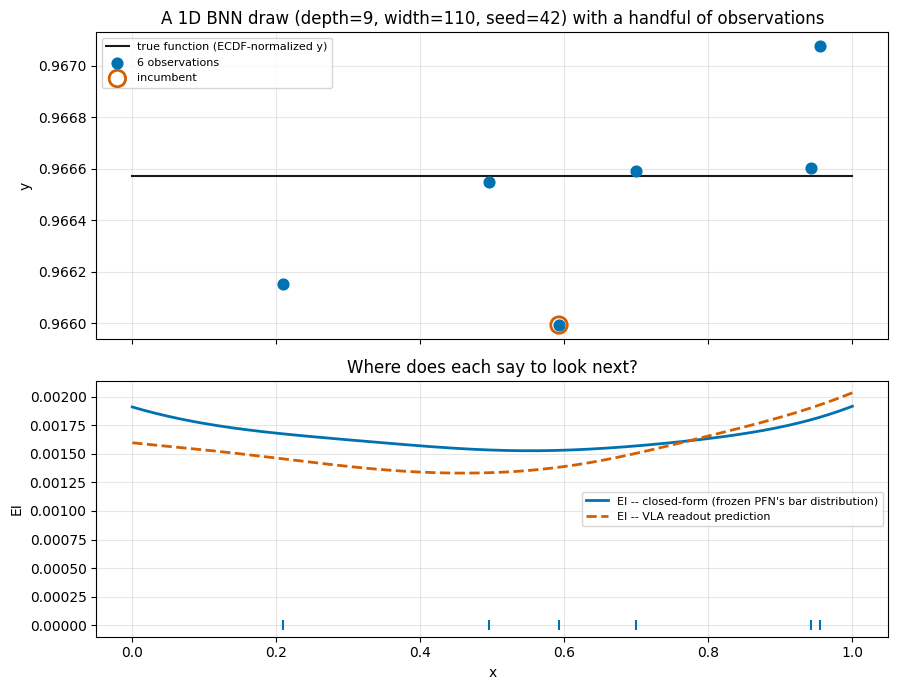

In [10]:

fig, axes = plt.subplots(2, 1, figsize=(9, 7), sharex=True, gridspec_kw={"height_ratios": [1.2, 1]})

axes[0].plot(x_grid_np, y_grid_true_np, color="#1a1a1a", linewidth=1.5, label="true function (ECDF-normalized y)")
axes[0].scatter(x_train_np, y_train_np, s=60, color="#0072B2", zorder=3, label=f"{N_TRAIN_SHOWCASE} observations")
axes[0].scatter([incumbent_x], [y_train_np.min()], s=140, facecolors="none", edgecolors="#D55E00",
                linewidths=2, zorder=4, label="incumbent")
axes[0].set_ylabel("y")
axes[0].set_title("A 1D BNN draw (depth=9, width=110, seed=42) with a handful of observations")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

axes[1].plot(x_grid_np, ei_true_np, color="#0072B2", linewidth=2, label="EI -- closed-form (frozen PFN's bar distribution)")
axes[1].plot(x_grid_np, ei_pred_np, color="#D55E00", linewidth=2, linestyle="--", label="EI -- VLA readout prediction")
axes[1].scatter(x_train_np, [0] * N_TRAIN_SHOWCASE, s=60, color="#0072B2", marker="|", zorder=3)
axes[1].set_xlabel("x")
axes[1].set_ylabel("EI")
axes[1].set_title("Where does each say to look next?")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

fig.tight_layout()
fig.savefig("_demo_plots/vla_readout_ei_fit_1d_showcase.png", dpi=150, bbox_inches="tight")
plt.show()
